In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [3]:
df = pd.read_csv("DATA.csv")
print(df.head())

                                            doi  \
0  https://doi.org/10.1016/j.corsci.2023.111017   
1  https://doi.org/10.1016/j.corsci.2023.111112   
2  https://doi.org/10.1016/j.corsci.2023.111025   
3  https://doi.org/10.1016/j.corsci.2023.111296   
4  https://doi.org/10.1016/j.corsci.2023.111591   

                                               title  year  citations  is_oa  \
0  Metastable pitting corrosion behavior and char...  2023        199   True   
1  On the use of the Langmuir and other adsorptio...  2023        164   True   
2  Experimental comparison of gaseous and electro...  2023        118   True   
3  Synergistic inhibition effect of Mikania micra...  2023        104   True   
4  Study on the oxidation behavior of a novel the...  2023        100   True   

                                            abstract       MWL        LC  \
0  This work investigated the metastable pitting ...  6.413174  0.419162   
1  In corrosion inhibition studies, the standard ...  6.8473

根据相关性分析的结果，优先选用JD作为自变量进行训练

In [8]:
X = df[["JD"]]
Y = df["citations"] 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
model = LinearRegression()
model.fit(X_train, Y_train)
print("截距和回归系数")
print(model.intercept_, model.coef_)

截距和回归系数
3.547755700816552 [216.72058111]


In [15]:
Y_pred = model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
print(mse,"\n", df['citations'].describe())

701.7896852911945 
 count    377.000000
mean      12.564987
std       19.167005
min        0.000000
25%        3.000000
50%        7.000000
75%       16.000000
max      199.000000
Name: citations, dtype: float64


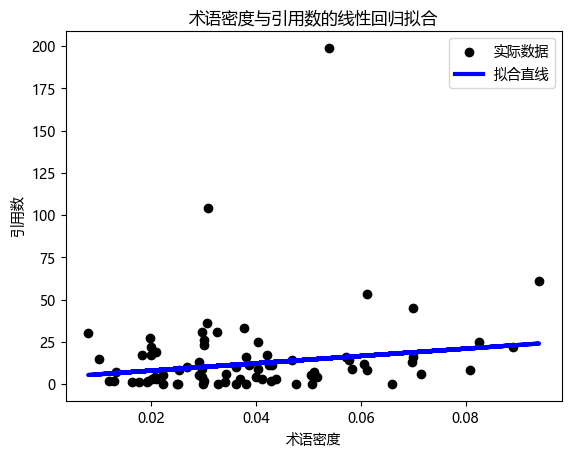

In [14]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.scatter(X_test, Y_test, color='black', label='实际数据')
plt.plot(X_test, model.predict(X_test), color='blue', linewidth=3, label='拟合直线')
plt.xlabel('术语密度')
plt.ylabel('引用数')
plt.legend()
plt.title('术语密度与引用数的线性回归拟合')
plt.show()

结论：
1. 术语密度特征已经是相关系数最高的特征，但拟合效果明显较差，考虑使用分类模型
2. 论文中提到引用数分布情况比较特殊，用线性回归效果可能一般，考虑做特殊处理？

In [ ]:

from sklearn

1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        23
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        18
           5       1.00      1.00      1.00        27
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       1.00      1.00      1.00        15
           9       1.00      1.00      1.00        15
          10       1.00      1.00      1.00         9
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00        10
          13       1.00      1.00      1.00         9
          14       1.00      1.00      1.00        12
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         7
          17       1.00    